# Data Preparation Pipeline

В этом ноутбуке мы разберем процесс подготовки и очистки данных для модели **Graph2Eq**. 
Изначальный датасет состоял из ~2.8 млн сгенерированных графиков и формул, однако сырые данные имели ряд критических проблем. Мы загрузим **реальный сырой чанк** и покажем, как наш пайплайн решает эти проблемы шаг за шагом.

In [1]:
import os
import sys
import gzip
import pickle
import numpy as np
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath('..'))

from src.tokenizer import Tokenizer
from src.data_prep.canonicalize import clean_item
from src.data_prep.normalize import raw_to_normalized_features

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

RAW_CHUNK_PATH = "../data_raw/chunk_0.pkl.gz"

with gzip.open(RAW_CHUNK_PATH, "rb") as f:
    raw_data = pickle.load(f)

print(f"Загружено {len(raw_data)} сырых примеров.")

Загружено 50000 сырых примеров.


## Шаг 1: Канонизация выражений (Удаление синонимов)

Модель генерирует скелеты формул (с плейсхолдерами `C`). Если в датасете присутствуют токены и `sin`, и `cos`, модель будет получать огромный штраф за правильные по сути предсказания, так как формы этих функций отличаются лишь фазовым сдвигом (константой `C`). 

Кроме того, нам нужно решить проблему коммутативности и ассоциативности ($C+C X$ и $C X+C$). Найдем в сырых данных формулу с косинусом и прогоним через `canonicalize`.

In [2]:
tokenizer = Tokenizer()

cos_item = next(item for item in raw_data if "cos" in item["expr_str"])

print("ДО КАНОНИЗАЦИИ (Сырой скелет):")
print(f"Строка: {cos_item['expr_str']}")
print(f"Токены: {cos_item['tokens']}\n")

cleaned_item = clean_item(cos_item, tokenizer)

print("ПОСЛЕ КАНОНИЗАЦИИ (Приведено к sin и отсортировано):")
print(f"Строка: {cleaned_item['expr_str']}") # type: ignore
print(f"Токены: {cleaned_item['tokens']}") # type: ignore

ДО КАНОНИЗАЦИИ (Сырой скелет):
Строка: C_2*cos(C_0 + C_1*x)
Токены: [1 9 4 6 5 4 9 4 3 2]

ПОСЛЕ КАНОНИЗАЦИИ (Приведено к sin и отсортировано):
Строка: C*sin(C*x + C) + C
Токены: [ 1  5  4  9  4 11  5  4  9  4  3  2]


## Шаг 2: Геометрическая чистка и Маскирование (Асимптоты)

Сырые графики могут содержать разрывы (например, $1/x$ или $tan(x)$). Если просто интерполировать их равномерно по $x$ на $[0, 1]$, то форма графика будет неверной. Также в данных встречаются выбросы из-за особенностей генерации.

Наш модуль `normalize.py`:
1. Выполняет независимый Min-Max Scale по оси Y. Это заставляет нейросеть учить **топологию**, а не масштаб.
2. Математически детектирует асимптоты по скачкам производной.
3. Создает канал **Mask**, в котором `0` означает разрыв.

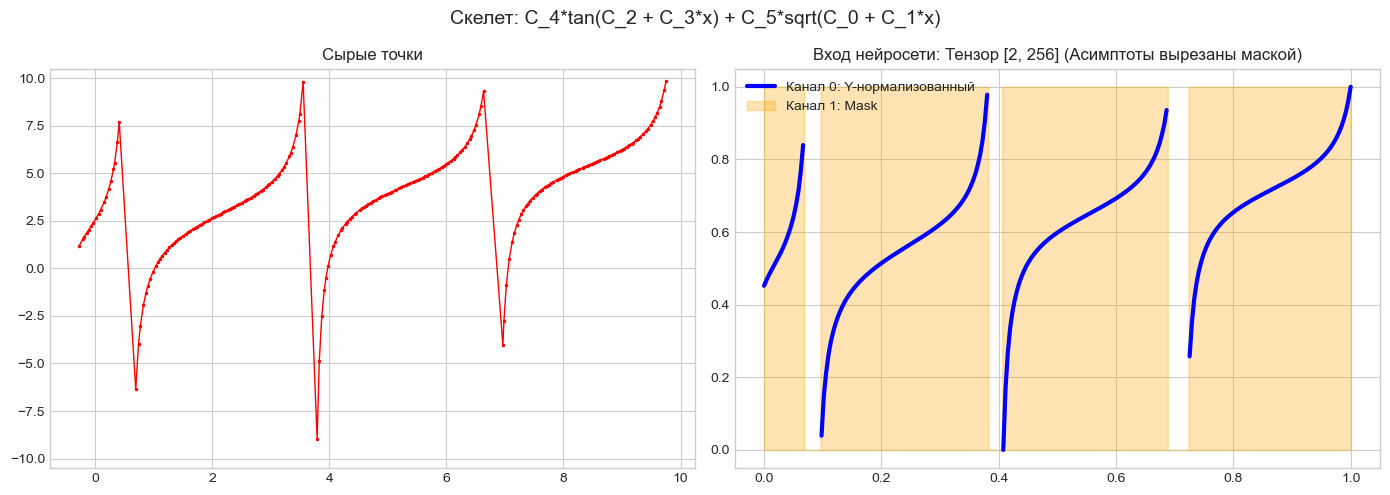

In [ ]:
def has_asymptote(pts):
    return np.max(np.abs(np.diff(pts[:, 1]))) > 5.0

items_iterator = (item for item in raw_data if has_asymptote(item["points"]))
asymp_item = next(items_iterator)
pts_raw = asymp_item["points"]

features = raw_to_normalized_features(pts_raw)
y_norm, mask = features[0], features[1] # type: ignore
x_fixed = np.linspace(0, 1, 256)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f"Скелет: {asymp_item['expr_str']}", fontsize=14)

ax1.plot(pts_raw[:, 0], pts_raw[:, 1], 'r-', marker='.', markersize=3, linewidth=1)
ax1.set_title("Сырые точки")
ax1.set_ylim(-10.5, 10.5)

y_plot = np.where(mask == 1.0, y_norm, np.nan) # Убираем линии там, где маска = 0
ax2.plot(x_fixed, y_plot, 'b-', linewidth=3, label="Канал 0: Y-нормализованный")
ax2.fill_between(x_fixed, 0, mask, color='orange', alpha=0.3, step='mid', label="Канал 1: Mask")
ax2.set_title("Вход нейросети: Тензор [2, 256] (Асимптоты вырезаны маской)")
ax2.set_xlim(-0.05, 1.05)
ax2.set_ylim(-0.05, 1.05)
ax2.legend(loc="upper left")

plt.tight_layout()
plt.show()

## Шаг 3: Удаление визуальных коллизий (Бритва Оккама)

При обрезании графика окном $[-10, 10]$ разные формулы могут выглядеть идентично. Например, сложный полином высокой степени на узком интервале может выглядеть как прямая линия.

Если мы оставим оба графика в датасете, модель не сойдется, так как за один и тот же визуальный вход она будет штрафоваться, если не угадает конкретную из 10 вариаций. Мы решили эту проблему, находя графики с $MAE < 0.03$ на GPU и оставляя только **самую короткую формулу** (Бритва Оккама).

Давайте найдем **реальную коллизию** прямо в загруженном чанке данных, сравнив первые 1000 примеров.

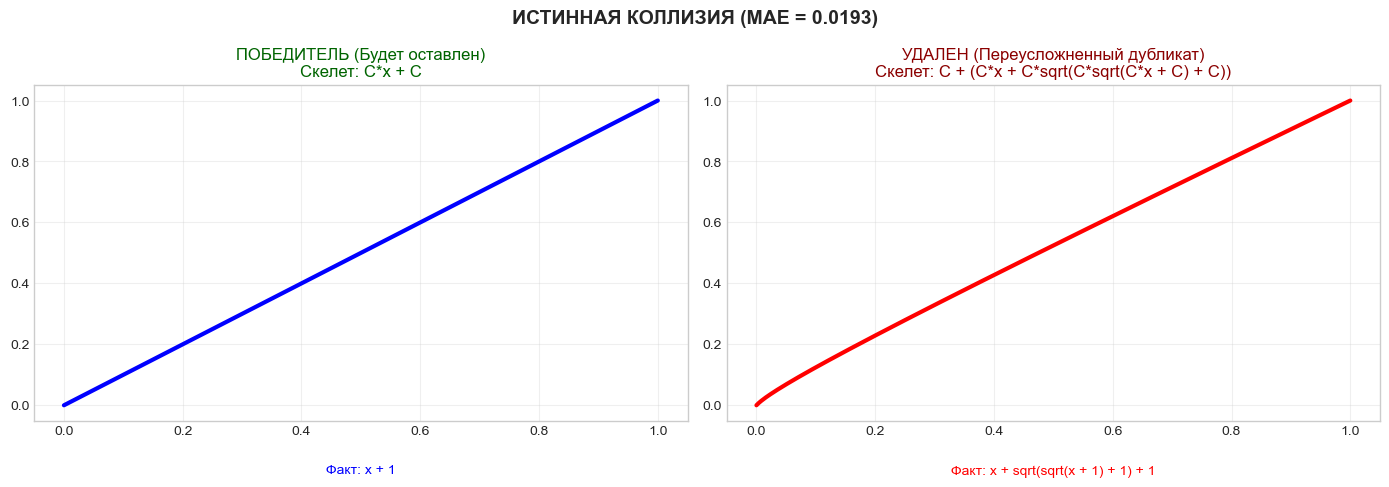

In [ ]:
subset = raw_data[2000:3000]
processed_subset =[]

for item in subset:
    cleaned = clean_item(item, tokenizer)
    if cleaned:
        feat = raw_to_normalized_features(cleaned["points"])
        if feat is not None:
            processed_subset.append((cleaned, feat))

collision_pair = None

for i in range(len(processed_subset)):
    for j in range(i + 1, len(processed_subset)):
        item1, feat1 = processed_subset[i]
        item2, feat2 = processed_subset[j]
        
        if item1["expr_str"] != item2["expr_str"]:
            y1, mask1 = feat1[0], feat1[1]
            y2, mask2 = feat2[0], feat2[1]
            
            common_mask = (mask1 == 1.0) & (mask2 == 1.0)
            if np.sum(common_mask) > 50:
                mae = np.abs(y1[common_mask] - y2[common_mask]).mean()
                max_err = np.abs(y1[common_mask] - y2[common_mask]).max()
                mask_mae = np.abs(mask1 - mask2).mean()
                
                if mae <= 0.03 and max_err <= 0.03 and mask_mae <= 0.012:
                    if len(item1["tokens"]) <= len(item2["tokens"]):
                        collision_pair = (item1, item2, feat1, feat2, mae)
                    else:
                        collision_pair = (item2, item1, feat2, feat1, mae)
                    break
    if collision_pair:
        break

if collision_pair:
    winner_item, loser_item, winner_feat, loser_feat, mae_val = collision_pair
    
    x_fixed = np.linspace(0, 1, 256)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f"ИСТИННАЯ КОЛЛИЗИЯ (MAE = {mae_val:.4f})", fontsize=14, fontweight='bold')
    
    y_win = np.where(winner_feat[1] == 1.0, winner_feat[0], np.nan)
    ax1.plot(x_fixed, y_win, 'b-', linewidth=3)
    ax1.set_title(f"ПОБЕДИТЕЛЬ (Будет оставлен)\nСкелет: {winner_item['expr_str'][:50]}", color='darkgreen')
    ax1.text(0.5, -0.15, f"Факт: {winner_item['expr_instantiated_str']}", ha='center', va='center', transform=ax1.transAxes, color='blue')
    ax1.set_ylim(-0.05, 1.05)
    ax1.grid(True, alpha=0.3)
    
    y_los = np.where(loser_feat[1] == 1.0, loser_feat[0], np.nan)
    ax2.plot(x_fixed, y_los, 'r-', linewidth=3)
    ax2.set_title(f"УДАЛЕН (Переусложненный дубликат)\nСкелет: {loser_item['expr_str'][:50]}", color='darkred')
    ax2.text(0.5, -0.15, f"Факт: {loser_item['expr_instantiated_str']}", ha='center', va='center', transform=ax2.transAxes, color='red')
    ax2.set_ylim(-0.05, 1.05)
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
else:
    print("Коллизии не найдены!")

## Итог: Формат входа для модели Seq2Seq

После выполнения `scripts/build_dataset.py` мы получаем директорию `data_cleared` с PyTorch тензорами `.pt`.

Каждый пример содержит:
- `points`: Tensor размера `[2, 256]` (Канал Y, Канал Маски).
- `tokens`: Tensor размера `[128]` (Индексы токенов скелета с паддингом).